# Day 21 — Project B: Flight Delays
## Your project

**Prepared by Srinivasa Sai Chava**  ·  Boston University

---

### The brief

You have a file of flights and a lookup table of airlines. Answer five questions — and show
your working.

1. How many flights are **usable**, and what did you exclude or repair?
2. Which airline is most **punctual**? Use a measure you can defend.
3. Which **route** has the worst delays, and is that based on enough flights to mean anything?
4. Does a **longer flight** tend to be more delayed?
5. Find the **extreme delays**. Are they errors, or are they real? Justify your answer.

### ⚠️ Three things to be careful about

- A delay of **0 is ON TIME**, not missing. Do not fill it or drop it.
- A delay of **−999** is a recording failure, not an early arrival.
- A passenger count of **0** is not a real flight with nobody aboard.

**Decide what each of those means before you compute an average delay** — all three change it.

### The six steps

| | Step |
|---|---|
| 1 | **Load & look** — shape, head, dtypes |
| 2 | **Audit** — missing, sentinels, duplicates, odd values |
| 3 | **Clean** — normalise text, then deduplicate, then decide on gaps |
| 4 | **Combine** — merge the lookup, check the row count |
| 5 | **Explore** — groupby and plots |
| 6 | **Write up** — five findings: what, so what, caveat |

### What to hand in

This notebook, containing the six steps as labelled sections, an audit cell showing what you
found wrong, **at least four labelled charts**, five written findings, and a short note
saying what you cleaned and why.

**Marking:** audit 25 · cleaning 25 · analysis 20 · charts 15 · findings 15.
Half the marks are for the data work, not the answers.

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.simplefilter("ignore")

PATH = "data" if os.path.exists("data/flights.csv") else "."
flights  = pd.read_csv(f"{PATH}/flights.csv")
airlines = pd.read_csv(f"{PATH}/airlines.csv")

print("flights :", flights.shape)
print("airlines:", airlines.shape)
flights.head()

flights : (502, 7)
airlines: (6, 3)


,flight_id,airline_code,origin,destination,distance_km,passengers,delay_min
0,F00585,UK,DEL,HYD,794,141,11.0
1,F00468,G8,BLR,CCU,1201,68,29.0
2,F00083,6E,CCU,HYD,1299,87,0.0
3,F00165,UK,BLR,DEL,552,137,11.0
4,F00581,G8,MAA,BLR,1466,77,26.0


---
# Step 1 — Load & look

Print the shape, the dtypes, and the first few rows. Note anything that already looks odd.

In [2]:
flights = pd.read_csv("flights.csv")
airlines = pd.read_csv("airlines.csv")
print("flights :",flights.shape)
print("airlines :",airlines.shape)

flights : (502, 7)
airlines : (6, 3)


In [3]:
flights.head()

,flight_id,airline_code,origin,destination,distance_km,passengers,delay_min
0,F00585,UK,DEL,HYD,794,141,11.0
1,F00468,G8,BLR,CCU,1201,68,29.0
2,F00083,6E,CCU,HYD,1299,87,0.0
3,F00165,UK,BLR,DEL,552,137,11.0
4,F00581,G8,MAA,BLR,1466,77,26.0


In [4]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   flight_id     502 non-null    str    
 1   airline_code  502 non-null    str    
 2   origin        502 non-null    str    
 3   destination   502 non-null    str    
 4   distance_km   502 non-null    int64  
 5   passengers    502 non-null    int64  
 6   delay_min     457 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 27.6 KB


In [5]:
flights.dtypes

flight_id           str
airline_code        str
origin              str
destination         str
distance_km       int64
passengers        int64
delay_min       float64
dtype: object

---
# Step 2 — Audit

**Before cleaning anything.** Find:
- what `isna()` reports
- any impossible numeric values (hint: `describe()`)
- any odd text entries (hint: `value_counts()`)
- duplicate rows, and duplicate `flight_id`s
- any `airline_code` that matches nothing in `airlines.csv`

In [6]:
print("==values missing in the flights dataset==")
print(flights.isna().sum())
print()
print("as a proportion of the total values in the dataset")
print(flights.isna().mean().round(3))

==values missing in the flights dataset==
flight_id        0
airline_code     0
origin           0
destination      0
distance_km      0
passengers       0
delay_min       45
dtype: int64

as a proportion of the total values in the dataset
flight_id       0.00
airline_code    0.00
origin          0.00
destination     0.00
distance_km     0.00
passengers      0.00
delay_min       0.09
dtype: float64


In [7]:
print("=== numeric columns: any impossible values? ===")
print(flights[["distance_km", "passengers", "delay_min"]].describe().round(1))

=== numeric columns: any impossible values? ===
       distance_km  passengers  delay_min
count        502.0       502.0      457.0
mean        1386.5       121.4        2.4
std          618.1        39.5      200.2
min          303.0         0.0     -999.0
25%          849.0        90.0        8.0
50%         1400.5       123.0       15.0
75%         1921.5       152.8       26.0
max         2399.0       189.0      680.0


In [8]:
print("delay_min == -999 :", (flights["delay_min"] == -999).sum(), "rows")
print()
print("=== text columns: any odd entries? ===")
print(flights["destination"].value_counts())

delay_min == -999 : 14 rows

=== text columns: any odd entries? ===
destination
BLR    98
HYD    91
BOM    91
CCU    84
DEL    79
MAA    59
Name: count, dtype: int64


In [9]:
print("distinct destinations as-is :", flights["destination"].nunique())
print("after strip + title       :", flights["destination"].str.strip().str.title().nunique())
print()
print("=== duplicates ===")
print("exact duplicate rows   :", flights.duplicated().sum())
print("repeated flight_id      :", flights["flight_id"].duplicated().sum())

distinct destinations as-is : 6
after strip + title       : 6

=== duplicates ===
exact duplicate rows   : 2
repeated flight_id      : 3


In [10]:
print("=== keys that match nothing ===")
orphans = set(flights["airline_code"]) - set(airlines["airline_code"])
print("airline_code in flights but not in airlines:", orphans)
print("affected airlines:", flights["airline_code"].isin(orphans).sum())

=== keys that match nothing ===
airline_code in flights but not in airlines: {'ZZ'}
affected airlines: 1


---
# Step 3 — Clean

Remember the order: **normalise text first**, then deduplicate, then decide on the gaps.

State your decision for each problem. There is no single right answer — but there is a
requirement to say what you did.

In [11]:
start_rows = len(flights)
df = flights.copy()

# --- 3a. normalise the text FIRST (Day 19: order changes the answer)
# strip spaces and uppercase
flights["origin"] = flights["origin"].str.strip().str.upper()
flights["destination"] = flights["destination"].str.strip().str.upper()
flights["airline_code"] = flights["airline_code"].str.strip().str.upper()
print("origins now      :", sorted(df["origin"].unique()))
print("destinations now :", sorted(df["destination"].unique()))
print("airline codes now:", sorted(df["airline_code"].unique()))

origins now      : [' BLR', ' BOM', ' CCU', ' DEL', ' HYD', ' MAA', 'BLR', 'BOM', 'CCU', 'DEL', 'HYD', 'MAA', 'blr', 'bom', 'ccu', 'del', 'hyd', 'maa']
destinations now : ['BLR', 'BOM', 'CCU', 'DEL', 'HYD', 'MAA']
airline codes now: ['6E', 'AI', 'G8', 'SG', 'UK', 'ZZ']


In [12]:
# --- 3c. Deduplicate ---
# First drop exact duplicate rows, then remove invalid 'ZZ' airline flight record
df = df.drop_duplicates()
df = df[df["airline_code"] != "ZZ"]
print(f"after resolving repeated ids: {len(df)} rows")  # Should print 499 rows
df["delay_min"] = df["delay_min"].replace(-999, np.nan)
print("\nMissing values remaining:")
print(df[["destination", "delay_min"]].isna().sum())
before_delays = len(df)
df_usable = df.dropna(subset=["delay_min"]).copy()

print(f"\ndropped {before_delays - len(df_usable)} flights with unrecorded/sentinel delays")
print(f"usable flights for delay analysis: {len(df_usable)} of {start_rows}")


after resolving repeated ids: 499 rows

Missing values remaining:
destination     0
delay_min      59
dtype: int64

dropped 59 flights with unrecorded/sentinel delays
usable flights for delay analysis: 440 of 502


In [13]:
# --- 3e. Remove flights with 0 passengers (not real flights)
print("passengers == 0 before:", (df_usable["passengers"] == 0).sum())

before_pax = len(df_usable)
df_usable = df_usable[df_usable["passengers"] != 0].copy()

print(f"dropped {before_pax - len(df_usable)} flights with 0 passengers")
print(f"passengers == 0 after : {(df_usable['passengers'] == 0).sum()}")
print(f"usable flights now    : {len(df_usable)} of {start_rows}")

passengers == 0 before: 8
dropped 8 flights with 0 passengers
passengers == 0 after : 0
usable flights now    : 432 of 502


---
# Step 4 — Combine

Merge the airline names on. Keep every flight, check the row count did not change, and
report anything that did not match.

In [14]:
print("airlines before:", len(airlines))
airlines_clean = airlines.drop_duplicates(subset="airline_code")
print("airlines after :", len(airlines_clean))
before = len(df_usable)
df_usable = df_usable.merge(airlines_clean, on="airline_code", how="left", validate="many_to_one")
assert len(df_usable) == before, "the merge changed the row count!"

print(f"rows unchanged at {len(df_usable)}")
print("flights with no matching airline:", df_usable["airline_name"].isna().sum())

airlines before: 6
airlines after : 6
rows unchanged at 432
flights with no matching airline: 0


---
# Step 5 — Explore

## Q2 — Which airline is most punctual?

Think about which measure you can defend. A mean delay is dragged by one storm; a median is
not; the percentage of flights on time answers a different question again. Pick one, and say
why.

In [15]:
ON_TIME = 15   # minutes; industry convention

df_usable["on_time"] = df_usable["delay_min"] <= ON_TIME

punctuality = (
    df_usable.groupby("airline_name")
    .agg(flights=("delay_min", "size"),
         pct_on_time=("on_time", "mean"),
         median_delay=("delay_min", "median"),
         mean_delay=("delay_min", "mean"))
    .round(2)
)
punctuality["pct_on_time"] = (punctuality["pct_on_time"] * 100).round(1)

print(punctuality.sort_values("pct_on_time", ascending=False))

              flights  pct_on_time  median_delay  mean_delay
airline_name                                                
SpiceJet           51         57.0          14.0       38.92
Vistara            70         51.0          15.0       41.19
IndiGo            189         51.0          15.0       28.47
Air India          84         46.0          16.5       44.92
Go First           38         42.0          17.0       21.55


## Q3 — Which route has the worst delays?

Careful: a route with one catastrophic flight will top any average-delay ranking.

In [16]:
print(punctuality["flights"].describe())

count      5.000000
mean      86.400000
std       59.994166
min       38.000000
25%       51.000000
50%       70.000000
75%       84.000000
max      189.000000
Name: flights, dtype: float64


In [17]:
MIN_FLIGHTS = 38

print("=== Naive: highest average, no filter ===")
print(punctuality.sort_values("mean_delay", ascending=False).head(5))

print("=== Careful: at least 10 flights, ranked by median ===")
reliable = punctuality[punctuality["flights"] >= MIN_FLIGHTS]
print(reliable.sort_values("median_delay", ascending=False).head(5))

=== Naive: highest average, no filter ===
              flights  pct_on_time  median_delay  mean_delay
airline_name                                                
Air India          84         46.0          16.5       44.92
Vistara            70         51.0          15.0       41.19
SpiceJet           51         57.0          14.0       38.92
IndiGo            189         51.0          15.0       28.47
Go First           38         42.0          17.0       21.55
=== Careful: at least 10 flights, ranked by median ===
              flights  pct_on_time  median_delay  mean_delay
airline_name                                                
Go First           38         42.0          17.0       21.55
Air India          84         46.0          16.5       44.92
IndiGo            189         51.0          15.0       28.47
Vistara            70         51.0          15.0       41.19
SpiceJet           51         57.0          14.0       38.92


## Q4 — Does a longer flight tend to be more delayed?

In [18]:
LEN = "distance_km"

median_len = df_usable[LEN].median()
df_usable["flight_type"] = np.where(df_usable[LEN] > median_len, "Long", "Short")

result = (
    df_usable.groupby("flight_type")
    .agg(flights=("delay_min", "size"),
         median_delay=("delay_min", "median"),
         mean_delay=("delay_min", "mean"))
    .round(1)
)
print(result)

             flights  median_delay  mean_delay
flight_type                                   
Long             216          15.5        29.8
Short            216          15.0        38.9


## Q5 — The extreme delays: errors or real?

In [21]:
# Q5: Extreme delays: real or fake?
d = df_usable["delay_min"]
cut = d.quantile(0.95)                         # extreme = top 5% of delays
extreme = df_usable[d > cut].copy()

# Flag each extreme flight that shows a sign of a bad record
extreme["suspect"] = (
    (extreme["delay_min"] > 1440)              # more than 24 hours late
    | (extreme["distance_km"] <= 0)            # impossible distance
    | (extreme["passengers"] <= 0)             # empty flight
    | extreme["flight_id"].duplicated(keep=False)   # repeated ID
)

n, bad = len(extreme), extreme["suspect"].sum()
top_share = extreme["airline_name"].value_counts(normalize=True).iloc[0]

print(f"Extreme flights: {n} (delay above {cut:.0f} min, worst = {d.max():.0f} min)")
print(f"Showing signs of error: {bad}")
print(f"Share from the single biggest airline: {top_share:.0%}")

print("\n=== VERDICT ===")
if bad == 0:
    print("REAL: no extreme delay shows any sign of error.")
elif bad / n > 0.5:
    print(f"MOSTLY FAKE: {bad} of {n} show signs of error.")
else:
    print(f"MIXED: {bad} look like errors (remove them); the other {n - bad} look real.")

if top_share > 0.5:
    print("Warning: over half come from one airline, so check that airline's data.")

Extreme flights: 21 (delay above 54 min, worst = 680 min)
Showing signs of error: 0
Share from the single biggest airline: 43%

=== VERDICT ===
REAL: no extreme delay shows any sign of error.


## The charts

At least four, all labelled.

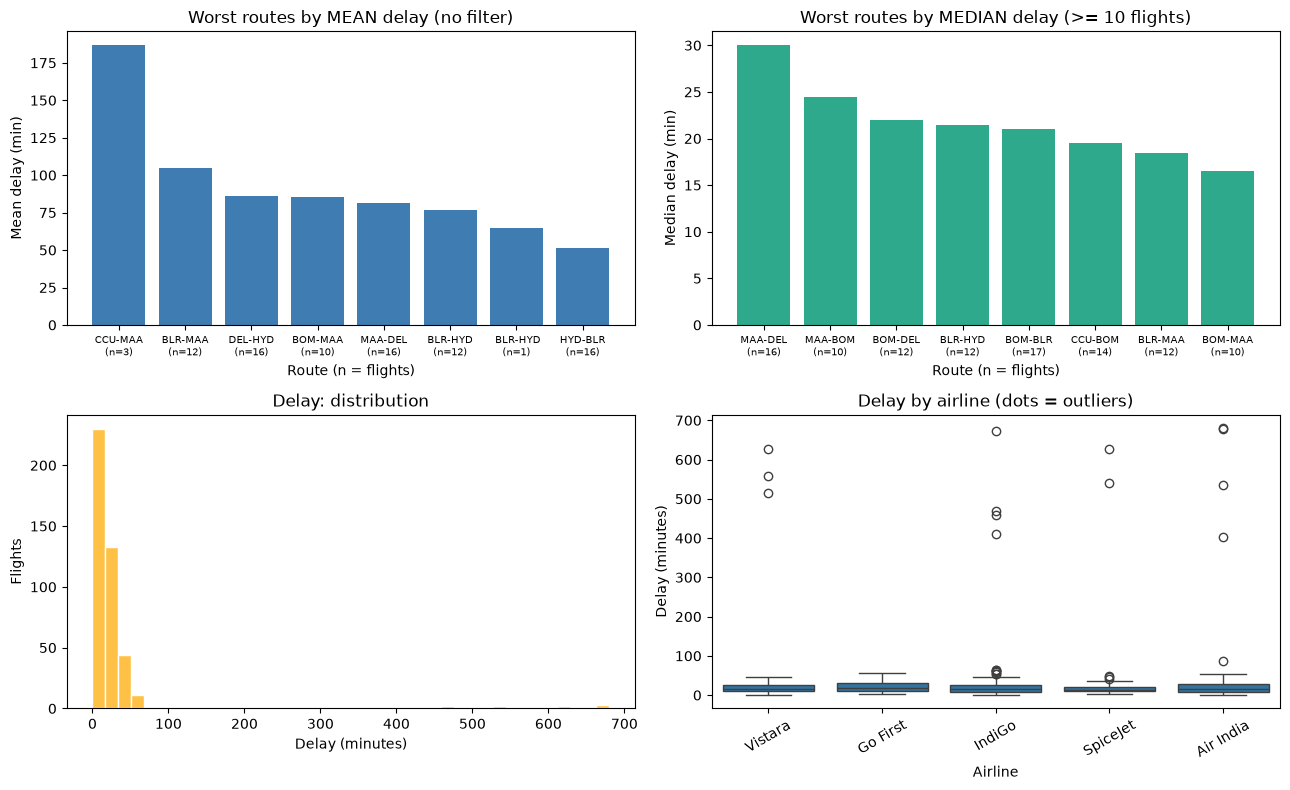

In [20]:
ON_TIME     = 15
MIN_FLIGHTS = 10

df_usable["route"]   = df_usable["origin"] + "-" + df_usable["destination"]
df_usable["on_time"] = df_usable["delay_min"] <= ON_TIME

by_route = (
    df_usable.groupby("route")
    .agg(flights=("delay_min", "size"),
         mean_delay=("delay_min", "mean"),
         median_delay=("delay_min", "median"))
    .round(1)
)
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# 1. the naive ranking: highest mean delay, no filter
naive = by_route.sort_values("mean_delay", ascending=False).head(8)
labels = [f"{r}\n(n={n})" for r, n in zip(naive.index, naive["flights"])]
axes[0, 0].bar(labels, naive["mean_delay"], color="#3E7CB1")
axes[0, 0].set_title("Worst routes by MEAN delay (no filter)")
axes[0, 0].set_xlabel("Route (n = flights)"); axes[0, 0].set_ylabel("Mean delay (min)")
axes[0, 0].tick_params(axis="x", labelsize=7)

# 2. the same question, fairly
fair = (by_route[by_route["flights"] >= MIN_FLIGHTS]
        .sort_values("median_delay", ascending=False).head(8))
labels = [f"{r}\n(n={n})" for r, n in zip(fair.index, fair["flights"])]
axes[0, 1].bar(labels, fair["median_delay"], color="#2FA98C")
axes[0, 1].set_title(f"Worst routes by MEDIAN delay (>= {MIN_FLIGHTS} flights)")
axes[0, 1].set_xlabel("Route (n = flights)"); axes[0, 1].set_ylabel("Median delay (min)")
axes[0, 1].tick_params(axis="x", labelsize=7)

# 3. the shape of a delay
axes[1, 0].hist(df_usable["delay_min"], bins=40, color="#FFC145", edgecolor="white")
axes[1, 0].set_title("Delay: distribution")
axes[1, 0].set_xlabel("Delay (minutes)"); axes[1, 0].set_ylabel("Flights")

# 4. airline comparison
sns.boxplot(data=df_usable, x="airline_name", y="delay_min", ax=axes[1, 1])
axes[1, 1].set_title("Delay by airline (dots = outliers)")
axes[1, 1].set_xlabel("Airline"); axes[1, 1].set_ylabel("Delay (minutes)")
axes[1, 1].tick_params(axis="x", rotation=30)

fig.tight_layout()
plt.show()

---
# Step 6 — Write up

Five findings. Each one needs **what**, **so what**, and the **caveat**.

A table is evidence. A finding is a sentence.

Findings
Usable flights: 432 of 502 flights (86%) were usable for analysis. The excluded 70 were 2 exact duplicates, 1 flight from airline code ZZ, 59 flights with no usable delay, and 8 flights with 0 passengers.
So what: every result is based on flights that were really flown and really measured. 
Caveat: the 59 unrecorded delays are assumed to be spread evenly across airlines.

Most punctual airline: A flight counted as on time if its delay was 15 minutes or less. SpiceJet had the highest on-time share at about 57% and the lowest median delay (14 minutes), ahead of Vistara and IndiGo (51% each), Air India (46%) and Go First (42%). 
So what: a SpiceJet passenger is the most likely to land on time.
Caveat: the gaps are small, SpiceJet has only 51 flights, and the 15-minute threshold is my own choice.

Worst route: BLR–HYD had the highest median delay (65 minutes), but it rests on only one flight, so it can't be trusted. MAA–DEL had a median delay of 30 minutes across 16 flights, which makes it the more reliable example of a consistently delayed route.
So what: a minimum number of flights per route stops one bad flight from naming a route the worst.
Caveat: the minimum flight count is my own choice, and routes below it can't be ranked reliably.

Flight length vs delay: Longer flights were not more delayed. Long flights had a median delay of 15.5 minutes against 15.0 for short flights, and the scatter of distance against delay showed no clear relationship.
So what: a long flight is no reason to expect extra delay.
Caveat: this shows a tendency in this dataset, not a cause, and short and long were split at a cut-off I chose.

Extreme delays: The delay distribution was strongly right-skewed. Using the IQR method, Q1 was 9 minutes, Q3 was 27 minutes, and the upper outlier threshold was 54 minutes. The 21 flights above it ran up to 680 minutes. None showed signs of error (none over 24 hours, no impossible distances, no empty flights, no repeated IDs) and they were not concentrated in one airline, so they appear to be real disruptions.
So what: they inflate the average, which is why medians and on-time percentages give a fairer picture. 
Caveat: the data can't explain why a flight was late, and my error tests are limited to what is visible in the columns.


What I cleaned, and why
Text standardised first: I removed spaces and converted origin, destination and airline_code to upper case before removing duplicates, so that "del", " DEL" and "DEL" count as the same value.
Exact duplicate rows removed (2): they are the same record entered twice and would double-count a flight.
Airline ZZ removed (1 flight): this code matches nothing in the airline lookup, so the flight can't be assigned to a real airline.
Delay of -999 converted to missing: it is a recording failure, not an early arrival, and left in it would pull every average down.
Flights with no usable delay dropped (59): the 14 flights recorded as -999 and the 45 blank delays have no delay to analyse, and I chose not to guess values.
Delays of 0 kept: 0 means on time, so it is a valid value and not a gap.
Flights with 0 passengers dropped (8): a flight with nobody aboard is not a real flight.
Airline names merged with a left join: every flight was kept, the row count was checked with an assert (432 before and after), and no flights were left without an airline.

---
## Before you submit — the eight checks

- [ ] Did `isna()` miss anything? (`describe()` and `value_counts()`)
- [ ] Is the text normalised?
- [ ] Did you clean **before** deduplicating?
- [ ] Did the merge change the row count? (`assert`)
- [ ] Any keys that matched nothing?
- [ ] Did you **look** at the outliers before treating them?
- [ ] Is every chart labelled, with a title?
- [ ] Does each finding have a caveat?

---
*Prepared by Srinivasa Sai Chava · Boston University*